Starting Breeden-Litzenberger Analysis
Ticker: AAPL

Note: Make sure you have installed required packages:
pip install yfinance numpy pandas scipy matplotlib

FETCHING DATA FOR: AAPL
Timestamp: 2025-09-27 13:52:23

Current Stock Price: $255.46

Available Expirations: 21
Selected Expiration: 2025-10-03
Days to Expiry: 6
Time to Maturity (τ): 0.0164 years

PREPARING OPTION DATA

Filtered Strike Range: $217.14 - $293.78
Number of Strikes Used: 31

Sample of Option Data (5 strikes around ATM):
    strike  midPrice   volume  impliedVolatility
32   250.0     6.600   4454.0           0.238655
33   252.5     4.775   2458.0           0.224617
34   255.0     3.250  18970.0           0.217293
35   257.5     2.040  34631.0           0.210945
36   260.0     1.210  64733.0           0.208992

APPLYING BREEDEN-LITZENBERGER FORMULA

Risk-free rate used: 5.00%

Density Grid Points: 200
Min Strike in Grid: $217.50
Max Strike in Grid: $292.50

DISTRIBUTION ANALYSIS

Expected Value: $241.89
Mode (Peak): $

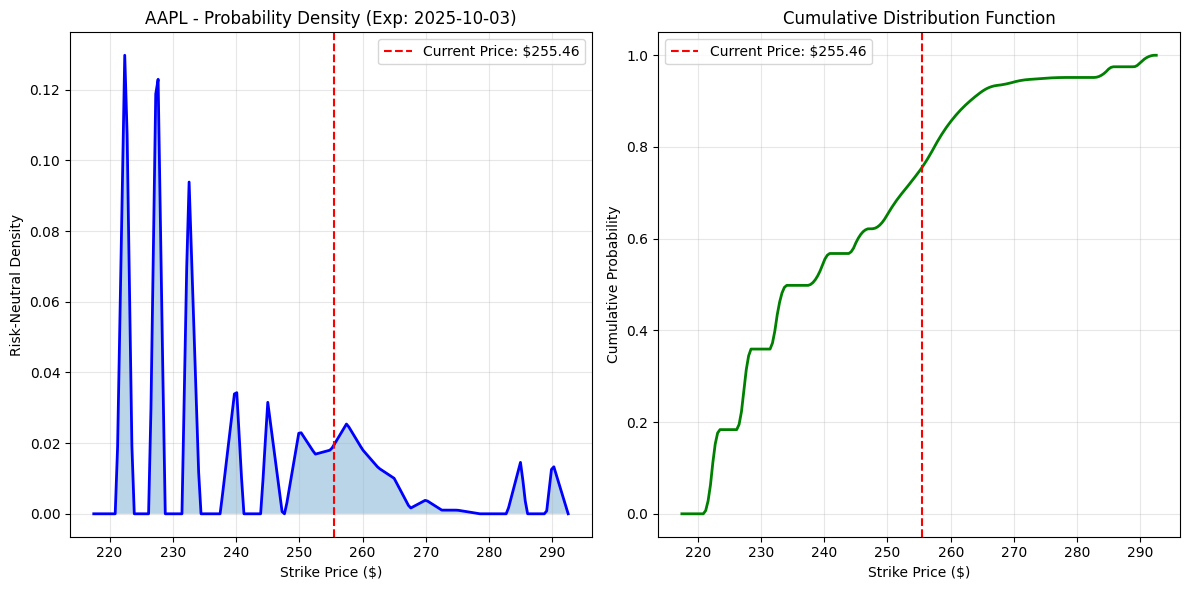


Plot saved as 'AAPL_breeden_litzenberger.png'

ANALYSIS COMPLETE

KEY INSIGHTS TO SHARE:
1. Check the Expected Value vs Current Price
2. Look at the Skew Indicator (market bias)
3. Review Tail Probabilities (risk perception)
4. Note the Annualized Volatility (uncertainty level)


In [6]:
import yfinance as yf
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

def get_option_data(ticker_symbol):
    """Retrieve option chain data for a given ticker"""
    print(f"\n{'='*60}")
    print(f"FETCHING DATA FOR: {ticker_symbol}")
    print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"{'='*60}")

    # Get ticker object
    ticker = yf.Ticker(ticker_symbol)

    # Get current stock price
    current_price = ticker.history(period='1d')['Close'].iloc[-1]
    print(f"\nCurrent Stock Price: ${current_price:.2f}")

    # Get available expiration dates
    expirations = ticker.options
    print(f"\nAvailable Expirations: {len(expirations)}")

    # Use the first available expiration (closest to current date)
    expiry = expirations[0]
    print(f"Selected Expiration: {expiry}")

    # Calculate time to maturity
    expiry_date = pd.to_datetime(expiry)
    current_date = pd.to_datetime(datetime.now().date())
    days_to_expiry = (expiry_date - current_date).days
    tau = days_to_expiry / 365.0
    print(f"Days to Expiry: {days_to_expiry}")
    print(f"Time to Maturity (τ): {tau:.4f} years")

    # Get option chain
    opt_chain = ticker.option_chain(expiry)
    calls = opt_chain.calls

    return calls, current_price, tau, expiry

def prepare_call_data(calls, current_price):
    """Clean and prepare call option data"""
    print(f"\n{'='*60}")
    print("PREPARING OPTION DATA")
    print(f"{'='*60}")

    # Filter for liquid options (near the money)
    lower_bound = current_price * 0.85
    upper_bound = current_price * 1.15

    filtered_calls = calls[(calls['strike'] >= lower_bound) &
                          (calls['strike'] <= upper_bound)].copy()

    # Use mid-price
    filtered_calls['midPrice'] = (filtered_calls['bid'] + filtered_calls['ask']) / 2

    # Remove options with zero or NaN prices
    filtered_calls = filtered_calls[filtered_calls['midPrice'] > 0].dropna(subset=['midPrice'])

    print(f"\nFiltered Strike Range: ${lower_bound:.2f} - ${upper_bound:.2f}")
    print(f"Number of Strikes Used: {len(filtered_calls)}")
    print(f"\nSample of Option Data (5 strikes around ATM):")

    # Find ATM index
    atm_idx = np.argmin(np.abs(filtered_calls['strike'].values - current_price))
    sample_start = max(0, atm_idx - 2)
    sample_end = min(len(filtered_calls), atm_idx + 3)

    sample_data = filtered_calls.iloc[sample_start:sample_end][['strike', 'midPrice', 'volume', 'impliedVolatility']]
    print(sample_data.to_string())

    return filtered_calls

def breeden_litzenberger(strikes, call_prices, r=0.05):
    """Apply Breeden-Litzenberger formula to extract risk-neutral density"""
    print(f"\n{'='*60}")
    print("APPLYING BREEDEN-LITZENBERGER FORMULA")
    print(f"{'='*60}")
    print(f"\nRisk-free rate used: {r:.2%}")

    # Create interpolation function
    cs = CubicSpline(strikes, call_prices, bc_type='natural')

    # Create fine grid for density calculation
    K_grid = np.linspace(strikes.min(), strikes.max(), 200)

    # Calculate second derivative
    second_derivative = cs(K_grid, 2)

    # Apply B-L formula: f(K) = e^(r*tau) * d²C/dK²
    # Note: tau is handled in the main function

    # Clean up negative densities (should be positive)
    second_derivative = np.maximum(second_derivative, 0)

    print(f"\nDensity Grid Points: {len(K_grid)}")
    print(f"Min Strike in Grid: ${K_grid.min():.2f}")
    print(f"Max Strike in Grid: ${K_grid.max():.2f}")

    return K_grid, second_derivative

def analyze_distribution(K_grid, density, current_price, tau, r=0.05):
    """Analyze the extracted probability distribution"""
    print(f"\n{'='*60}")
    print("DISTRIBUTION ANALYSIS")
    print(f"{'='*60}")

    # Scale density by discount factor
    scaled_density = np.exp(r * tau) * density

    # Normalize to get probabilities (integrate to 1)
    dK = K_grid[1] - K_grid[0]
    total_prob = np.sum(scaled_density) * dK
    normalized_density = scaled_density / total_prob

    # Calculate statistics
    mean = np.sum(K_grid * normalized_density) * dK
    variance = np.sum((K_grid - mean)**2 * normalized_density) * dK
    std_dev = np.sqrt(variance)

    # Find mode (peak of distribution)
    mode_idx = np.argmax(normalized_density)
    mode = K_grid[mode_idx]

    # Calculate skewness indicator
    atm_idx = np.argmin(np.abs(K_grid - current_price))
    left_mass = np.sum(normalized_density[:atm_idx]) * dK
    right_mass = np.sum(normalized_density[atm_idx:]) * dK

    print(f"\nExpected Value: ${mean:.2f}")
    print(f"Mode (Peak): ${mode:.2f}")
    print(f"Standard Deviation: ${std_dev:.2f}")
    print(f"Annualized Volatility: {(std_dev/current_price) / np.sqrt(tau):.2%}")

    print(f"\nProbability Mass Distribution:")
    print(f"  Left of Current Price:  {left_mass:.2%}")
    print(f"  Right of Current Price: {right_mass:.2%}")
    print(f"  Skew Indicator: {'Negative (crash fears)' if left_mass > right_mass else 'Positive (upside bias)'}")

    # Tail analysis
    tail_threshold = 0.05  # 5% moves
    lower_tail = current_price * (1 - tail_threshold)
    upper_tail = current_price * (1 + tail_threshold)

    lower_tail_prob = np.sum(normalized_density[K_grid < lower_tail]) * dK
    upper_tail_prob = np.sum(normalized_density[K_grid > upper_tail]) * dK

    print(f"\nTail Probabilities (beyond ±5% move):")
    print(f"  Downside (<${lower_tail:.2f}): {lower_tail_prob:.2%}")
    print(f"  Upside (>${upper_tail:.2f}): {upper_tail_prob:.2%}")

    return normalized_density, mean, std_dev, mode

def plot_results(K_grid, density, current_price, ticker, expiry):
    """Visualize the risk-neutral density"""
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(K_grid, density, 'b-', linewidth=2)
    plt.axvline(current_price, color='r', linestyle='--', label=f'Current Price: ${current_price:.2f}')
    plt.fill_between(K_grid, density, alpha=0.3)
    plt.xlabel('Strike Price ($)')
    plt.ylabel('Risk-Neutral Density')
    plt.title(f'{ticker} - Probability Density (Exp: {expiry})')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    # Calculate cumulative distribution
    dK = K_grid[1] - K_grid[0]
    cumulative = np.cumsum(density) * dK
    plt.plot(K_grid, cumulative, 'g-', linewidth=2)
    plt.axvline(current_price, color='r', linestyle='--', label=f'Current Price: ${current_price:.2f}')
    plt.xlabel('Strike Price ($)')
    plt.ylabel('Cumulative Probability')
    plt.title('Cumulative Distribution Function')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{ticker}_breeden_litzenberger.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nPlot saved as '{ticker}_breeden_litzenberger.png'")

def main(ticker_symbol='MSFT'):
    """Main function to run the Breeden-Litzenberger analysis"""
    try:
        # Get option data
        calls, current_price, tau, expiry = get_option_data(ticker_symbol)

        # Prepare data
        filtered_calls = prepare_call_data(calls, current_price)

        # Extract strikes and prices
        strikes = filtered_calls['strike'].values
        call_prices = filtered_calls['midPrice'].values

        # Apply Breeden-Litzenberger
        K_grid, second_derivative = breeden_litzenberger(strikes, call_prices)

        # Analyze distribution
        normalized_density, mean, std_dev, mode = analyze_distribution(
            K_grid, second_derivative, current_price, tau
        )

        # Plot results
        plot_results(K_grid, normalized_density, current_price, ticker_symbol, expiry)

        print(f"\n{'='*60}")
        print("ANALYSIS COMPLETE")
        print(f"{'='*60}")
        print("\nKEY INSIGHTS TO SHARE:")
        print("1. Check the Expected Value vs Current Price")
        print("2. Look at the Skew Indicator (market bias)")
        print("3. Review Tail Probabilities (risk perception)")
        print("4. Note the Annualized Volatility (uncertainty level)")

        return K_grid, normalized_density

    except Exception as e:
        print(f"\nERROR: {str(e)}")
        print("Common issues:")
        print("- Market might be closed (try during market hours)")
        print("- Ticker might be invalid")
        print("- No liquid options available")
        return None, None

if __name__ == "__main__":
    # You can change the ticker here
    ticker = "AAPL"  # Try MSFT, AAPL, SPY, etc.

    print("Starting Breeden-Litzenberger Analysis")
    print(f"Ticker: {ticker}")

    # Install required packages if needed
    print("\nNote: Make sure you have installed required packages:")
    print("pip install yfinance numpy pandas scipy matplotlib")

    K_grid, density = main(ticker)